## CMPINF 2100 Week 06
### Visualizing combinations between multiple categorical variables

This video shows how to visually explore the combinations between two categorical variables. It shows why the Seaborn FIGURE LEVEL functions are useful because multiple subplots (known as FACETS) can be created WITHOUT for-loops. The facet can be associated with a second categorical variable to create the FACETED BAR CHART. Another way to visualize combinations is with the DODGED BAR CHART. The video shows how to use the Seaborn hue argument to associate a second categorical variable with the bar color. These concepts apply to combinations of 3 variables. The video concludes by showing an alternative plot type for showing combinations, the heat map. This plot type is particularly good as showing which combinations are NOT present in a data set. The Seaborn AXIS LEVEL function sns.heatmap() is combined with the pd.crosstab() function to visualize the cross-tabulation of the categories.

We previoulsy learned how to show the MARGINAL count for the categories of a SINGLE categorical variable. We will now learn how to examine the COMBINATION or RELATIONSHIP between several categorical variables.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

## REad data
we will use the Penguins data

In [3]:
penguins = sns.load_dataset('penguins')

In [4]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


## Marginal Counts

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


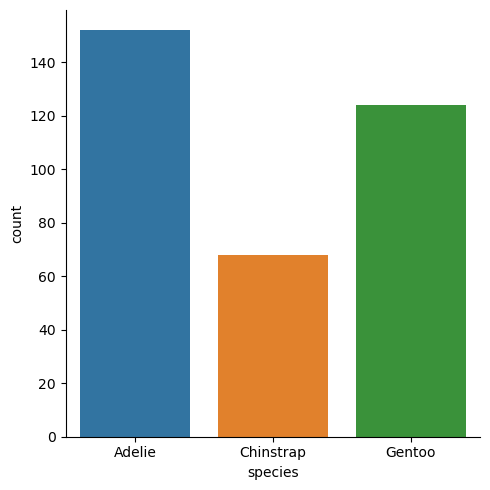

In [5]:
sns.catplot( data = penguins, x='species', kind='count', hue='species')
plt.show()

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


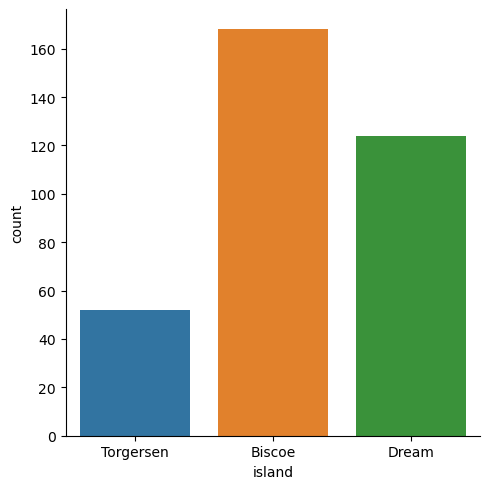

In [6]:
sns.catplot( data = penguins, x='island', kind='count', hue='island')
plt.show()

But what is the relationship between these two categorical variables? Or...what are the COUNTS for the **Combinations** between the two categorical variables???

Let's first use '.groupby()' method to apply the .size() method to each Unique COMBINATIONS!!!

In [10]:
penguins.groupby(['species', 'island']).size().reset_index(name='num_rows')

,species,island,num_rows
0,Adelie,Biscoe,44
1,Adelie,Dream,56
2,Adelie,Torgersen,52
3,Chinstrap,Dream,68
4,Gentoo,Biscoe,124


Let's confrime what's happening by filtering the data

In [11]:
penguins.loc[(penguins.species == 'Adelie') & (penguins.island == 'Biscoe'), :].shape

(44, 7)

### Visualize combinations
combinations can be shown using bar charts through subplots or **facets**. A facet is another term for subplot

Seaborn allows associating subplots or **facets** within columns in dataframe

Facets can only be easily created using figure level functions in seaborn. 
This is known as a FACETED BAR CHART

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


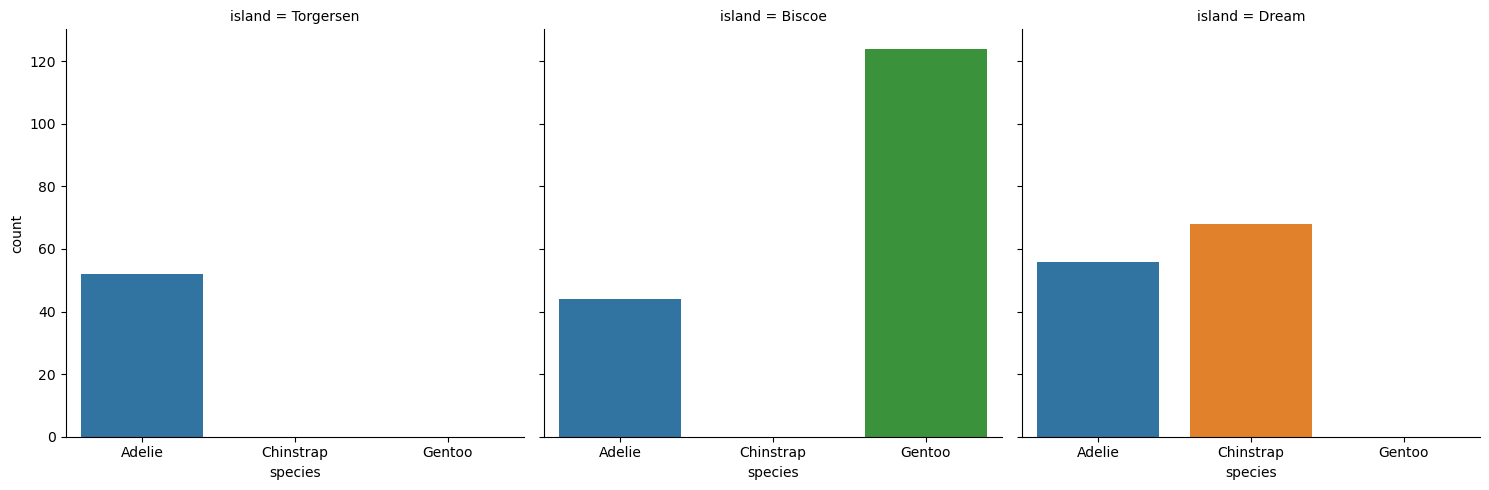

In [15]:
sns.catplot(data=penguins, x='species', col='island', kind='count', hue='species')
plt.show()

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


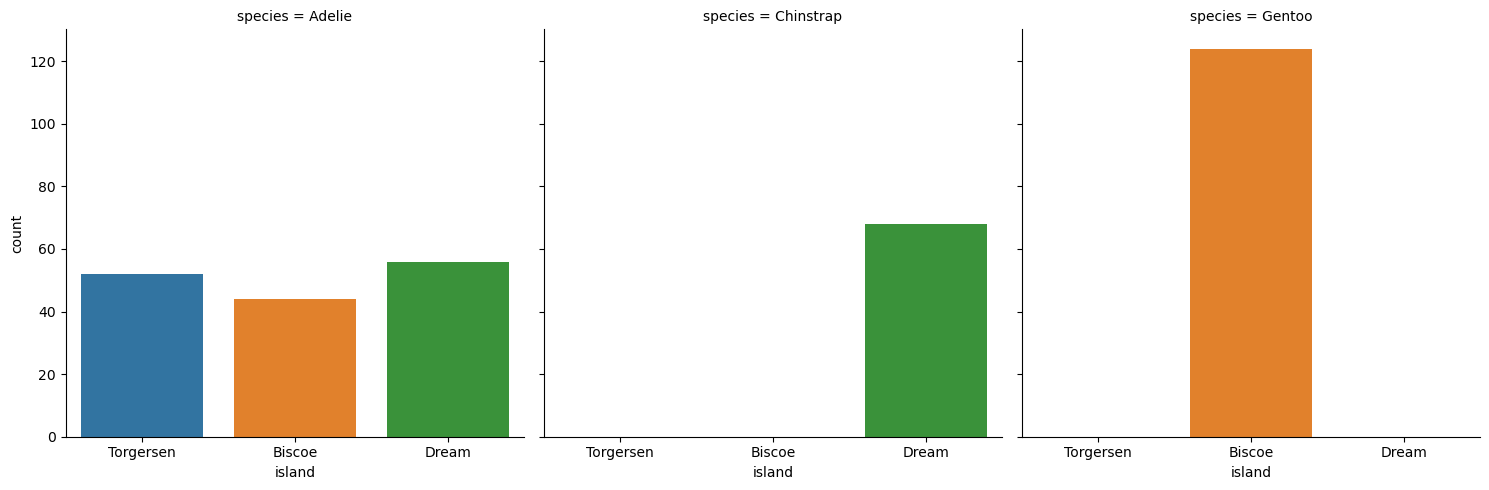

In [18]:
sns.catplot( data = penguins, x='island', col='species', kind='count', hue='island')
plt.show()

Alternatively we could use ROW facets

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


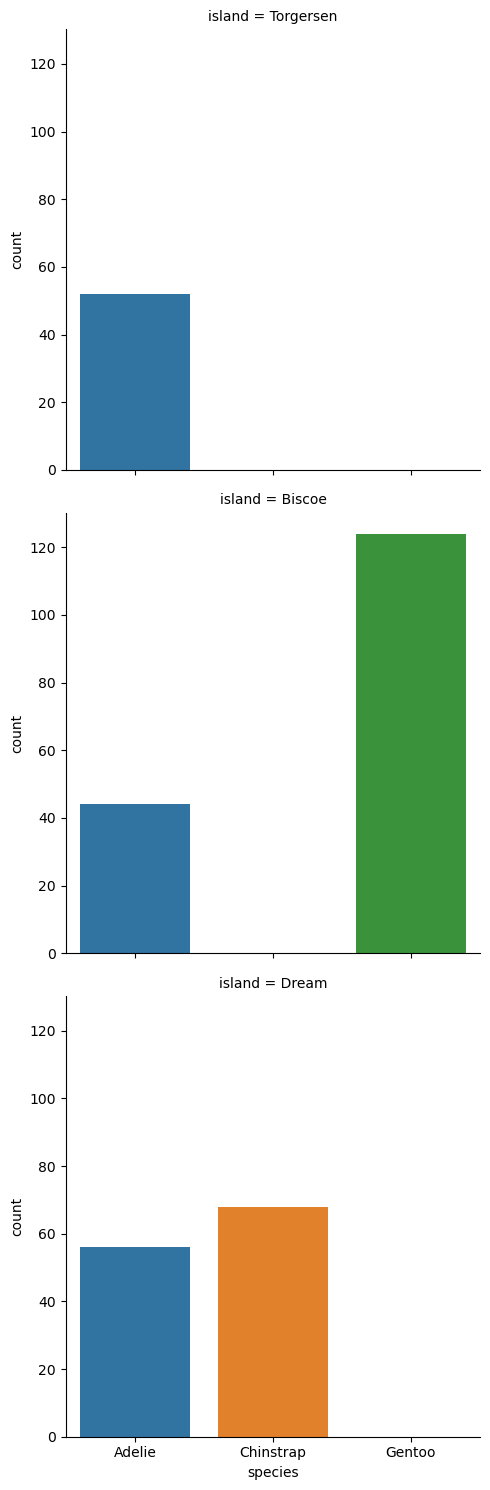

In [21]:
sns.catplot(data = penguins, x='species', row='island', kind='count', hue='species')

plt.show()

A more common way of showing the combination via bar charts with the **DODGED BAR CHART**.

The second categorical variable is used to color the bar!!!

Assicating color with a column variable with the dataframe is known as the hue agument

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


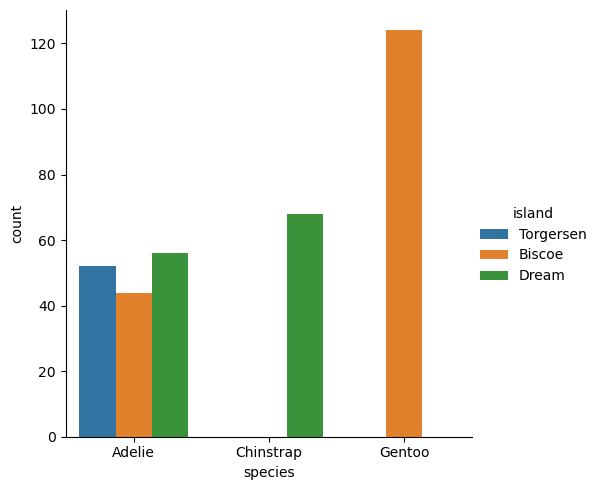

In [23]:
sns.catplot( data = penguins, x='species', hue='island', kind='count' )
plt.show()

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


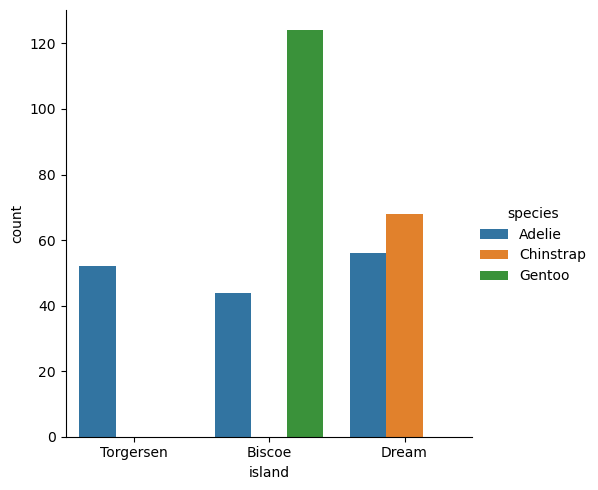

In [24]:
sns.catplot( data = penguins, x='island', hue='species', kind='count' )
plt.show()

We can use faceted bar charts and dodged bar charts to deal with the combination of 3 categorical variables.

For faceted bar charts, we can use one variable for ROW facets and another for COLUMN facets

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


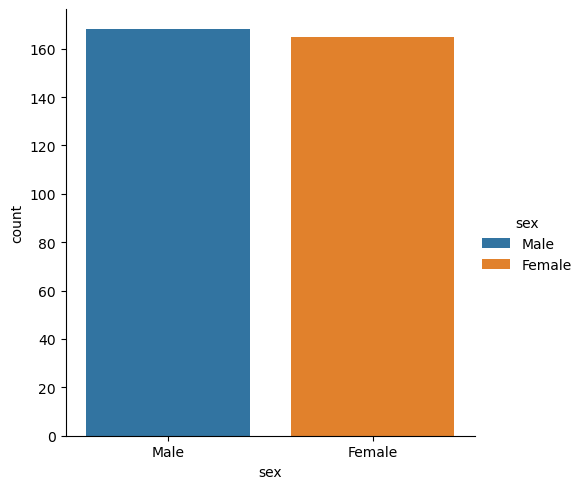

In [26]:
sns.catplot( data = penguins, x='sex', kind='count', hue='sex')
plt.show()

In [27]:
penguins.groupby(['species', 'island', 'sex']).size().reset_index(name='num_rows')

,species,island,sex,num_rows
0,Adelie,Biscoe,Female,22
1,Adelie,Biscoe,Male,22
2,Adelie,Dream,Female,27
3,Adelie,Dream,Male,28
4,Adelie,Torgersen,Female,24
5,Adelie,Torgersen,Male,23
6,Chinstrap,Dream,Female,34
7,Chinstrap,Dream,Male,34
8,Gentoo,Biscoe,Female,58
9,Gentoo,Biscoe,Male,61


/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


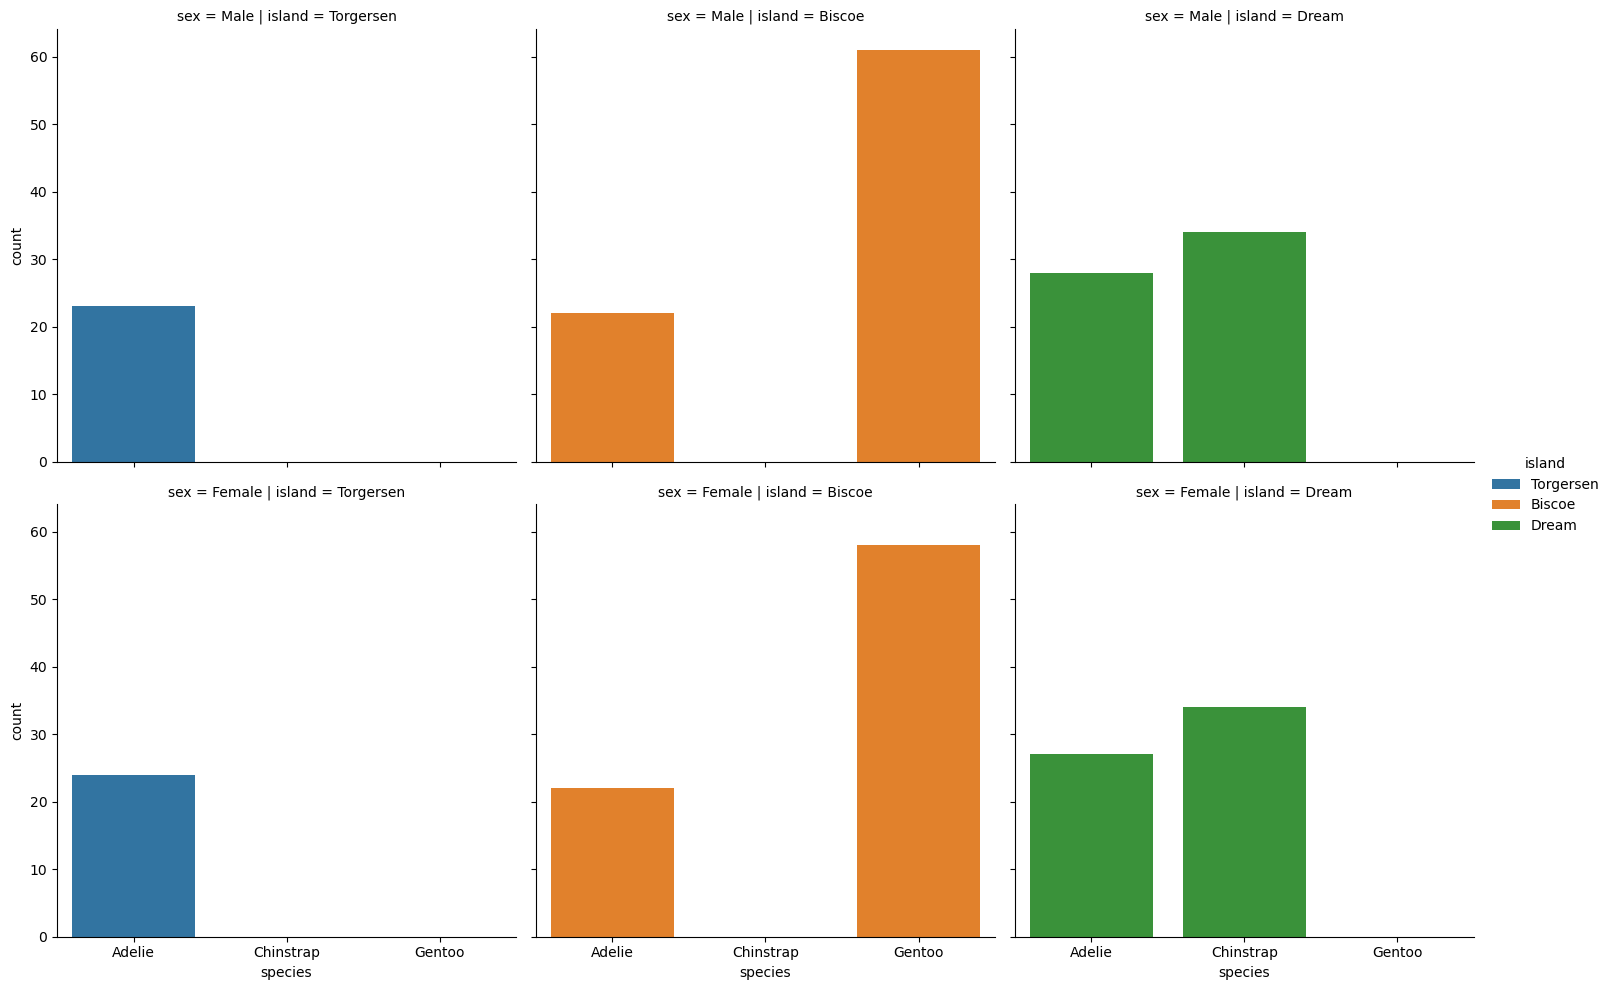

In [30]:
sns.catplot(data = penguins, x='species', row='sex', col='island', kind='count', hue='island')
plt.show()

3 categorical can be shown with dodged bar charts because 1 of the variables must be assigned to the facet!!!

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


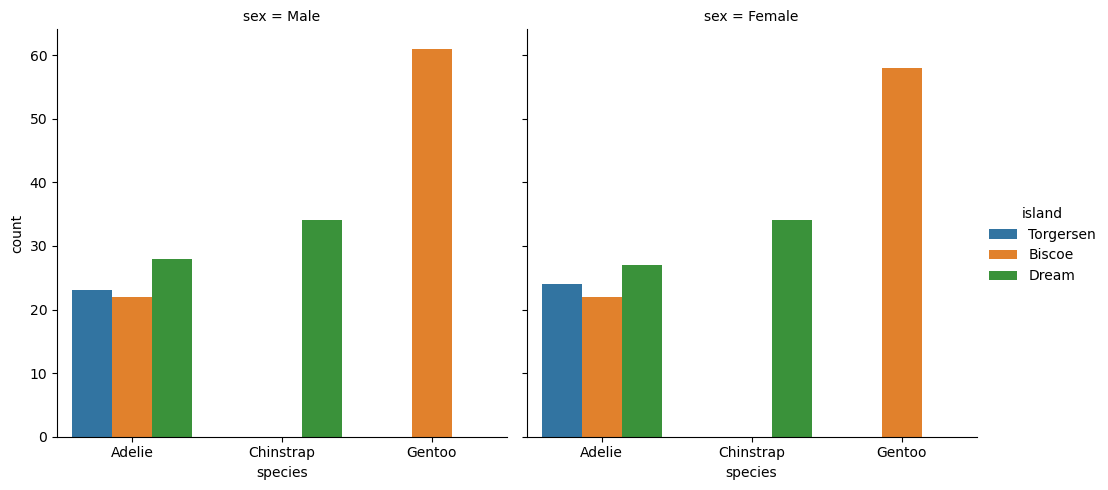

In [31]:
sns.catplot( data = penguins, x='species', hue='island', col = 'sex', kind='count' )
plt.show()

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


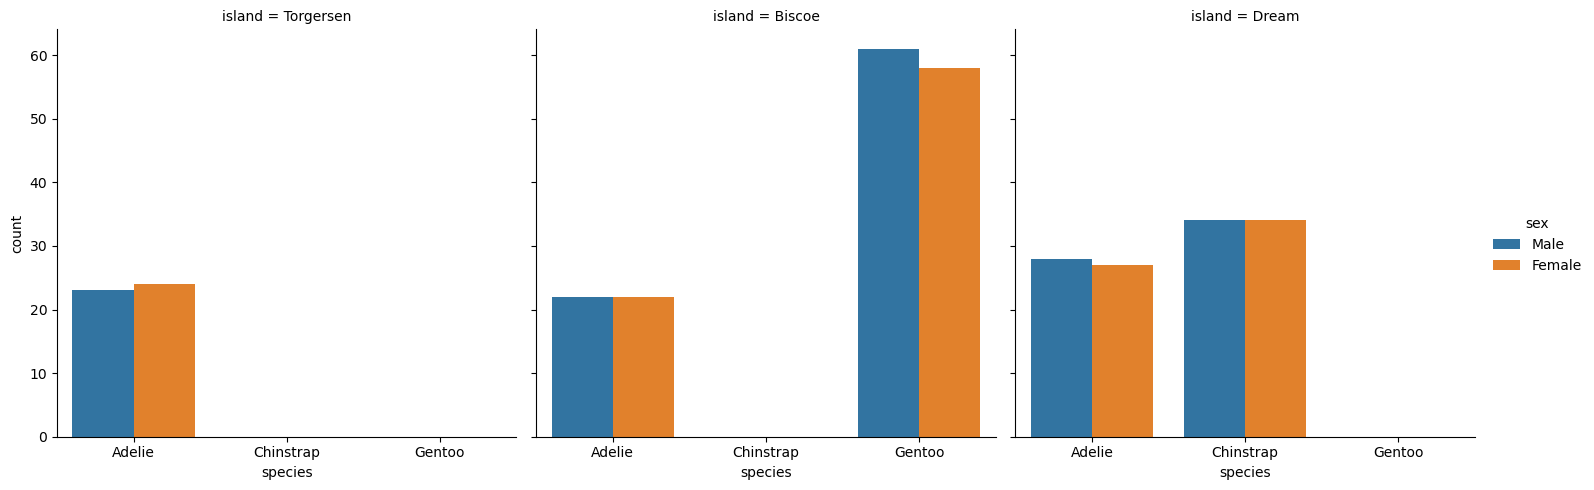

In [33]:
sns.catplot(data = penguins, x='species', hue='sex', col='island', kind='count')
plt.show()

## Heat maps

Bar charts show counts via the height of the bar. Heat maps show the count via color within the tile.

Let's first look at the raw data, focusing on the combination of 2 categorical variables.

In [34]:
penguins.groupby(['species', 'island']).size().reset_index(name='num_rows')

,species,island,num_rows
0,Adelie,Biscoe,44
1,Adelie,Dream,56
2,Adelie,Torgersen,52
3,Chinstrap,Dream,68
4,Gentoo,Biscoe,124


We need to reshare or reformat the way the counts are organinzed. We need the values for the categoricals to be the COLUMN NAMES and the ROW INDEX. The values in the cell are the COUNTS for the combinations.

The easiset way to create the counts this way with the pd.crosstab() function

In [36]:
pd.crosstab( penguins.species, penguins.island )

island,Biscoe,Dream,Torgersen
species,,,
Adelie,44,56,52
Chinstrap,0,68,0
Gentoo,124,0,0


In [37]:
penguins.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

The counts for the combinations can be visualized through the 'sns.heatmap()'. This is an AXES level function that wants the data organized in the style of 'pd.crosstab()'.

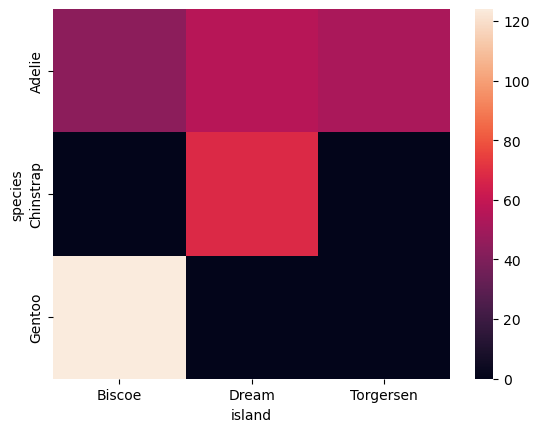

In [39]:
fig, ax = plt.subplots()

sns.heatmap(pd.crosstab(penguins.species, penguins.island), ax = ax )

plt.show()

It is easy to annotate on sns.heatmap(), i.e. include text so ewe can read the number and see the color

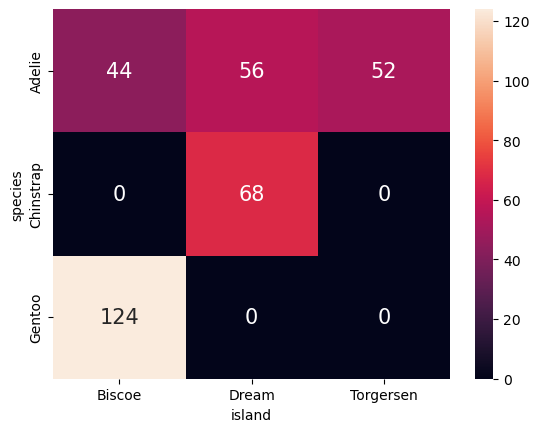

In [48]:
fig, ax = plt.subplots()

sns.heatmap( pd.crosstab(penguins.species, penguins.island ), ax = ax,
            annot=True, annot_kws={'size': 15}, fmt='d' )
plt.show()

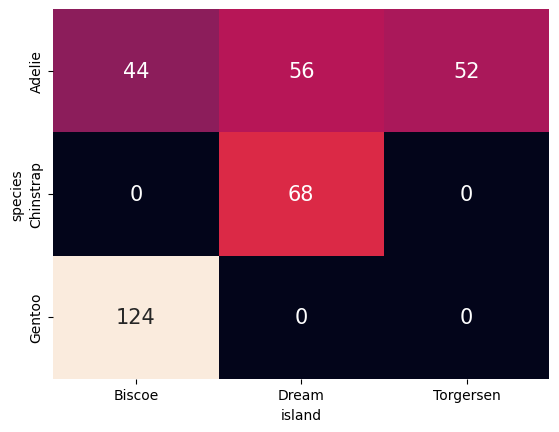

In [49]:
fig, ax = plt.subplots()

sns.heatmap( pd.crosstab(penguins.species, penguins.island ), ax = ax,
            annot=True, annot_kws={'size': 15}, fmt='d', cbar=False )
plt.show()

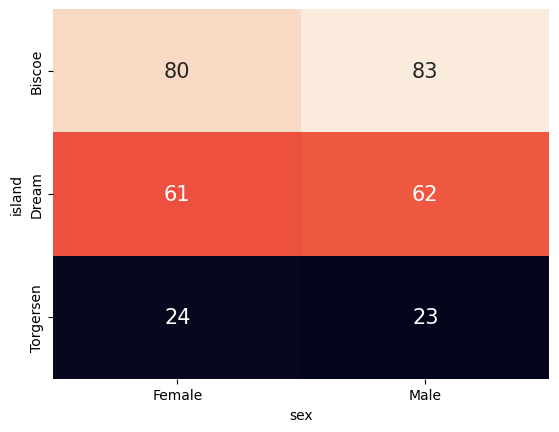

In [55]:
fig, ax = plt.subplots()

sns.heatmap(pd.crosstab(penguins.island, penguins.sex), ax = ax,
annot=True, annot_kws={'size': 15}, cbar=False )
plt.show()